In [1]:
from pathlib import Path

label_folders = [
    r"D:\Major Project\Self-Driving Cars.yolov8\train\labels",
    r"D:\Major Project\Self-Driving Cars.yolov8\valid\labels",
    r"D:\Major Project\Self-Driving Cars.yolov8\test\labels"
]

counts = {}

for folder in label_folders:
    for txt_file in Path(folder).glob("*.txt"):
        with open(txt_file, "r") as f:
            num_objects = len([line for line in f if line.strip()])
        counts[num_objects] = counts.get(num_objects, 0) + 1

print("Objects per Image:")
for k in sorted(counts):
    print(f"{k} object(s): {counts[k]} images")

Objects per Image:
0 object(s): 4 images
1 object(s): 4209 images
2 object(s): 556 images
3 object(s): 125 images
4 object(s): 67 images
5 object(s): 5 images
6 object(s): 1 images
7 object(s): 1 images
10 object(s): 1 images


In [2]:
# ==========================================================
# 🟢 PART A - STEP 1 : Environment Verification
# ==========================================================

import sys
import tensorflow as tf
import cv2
import matplotlib

print("="*65)
print("🚀 EfficientNet-B0 Traffic Sign Classification")
print("="*65)

print("\n📌 Python")
print("Version     :", sys.version)
print("Executable  :", sys.executable)

print("\n📌 TensorFlow")
print("Version     :", tf.__version__)

print("\n📌 OpenCV")
print("Version     :", cv2.__version__)

print("\n📌 Matplotlib")
print("Version     :", matplotlib.__version__)

print("\n📌 GPU")

gpus = tf.config.list_physical_devices("GPU")

if len(gpus):

    print("GPU Available :", len(gpus))
    print("GPU Name      :", gpus[0].name)

else:

    print("❌ GPU NOT Available")

print("\n"+"="*65)
print("✅ STEP 1 COMPLETED")
print("="*65)

🚀 EfficientNet-B0 Traffic Sign Classification

📌 Python
Version     : 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
Executable  : c:\Program Files\Python312\python.exe

📌 TensorFlow
Version     : 2.21.0

📌 OpenCV
Version     : 4.13.0

📌 Matplotlib
Version     : 3.11.0

📌 GPU
❌ GPU NOT Available

✅ STEP 1 COMPLETED


In [3]:
# ==========================================================
# 🟢 PART A - STEP 2 : Verify PyTorch GPU
# ==========================================================

import torch
import torchvision

print("=" * 65)
print("🚀 PyTorch Environment")
print("=" * 65)

print(f"PyTorch Version      : {torch.__version__}")
print(f"TorchVision Version  : {torchvision.__version__}")

print(f"\nCUDA Available       : {torch.cuda.is_available()}")

if torch.cuda.is_available():

    print(f"GPU Name             : {torch.cuda.get_device_name(0)}")

    print(f"CUDA Version         : {torch.version.cuda}")

    total_memory = torch.cuda.get_device_properties(0).total_memory / (1024**3)

    print(f"GPU Memory           : {total_memory:.2f} GB")

else:

    print("❌ GPU NOT Available")

print("=" * 65)
print("✅ STEP 2 COMPLETED")
print("=" * 65)

🚀 PyTorch Environment
PyTorch Version      : 2.12.1+cu126
TorchVision Version  : 0.27.1+cu126

CUDA Available       : True
GPU Name             : NVIDIA GeForce RTX 3050 6GB Laptop GPU
CUDA Version         : 12.6
GPU Memory           : 6.00 GB
✅ STEP 2 COMPLETED


In [5]:
# ==========================================================
# 🟢 PART B - STEP 1 : Convert YOLO Dataset to Classification Dataset
# ==========================================================

import cv2
import yaml
import shutil
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict

# ----------------------------------------------------------
# Source Dataset
# ----------------------------------------------------------

SOURCE_DATASET = Path(r"D:\Major Project\Self-Driving Cars.yolov8")

# ----------------------------------------------------------
# Destination Dataset
# ----------------------------------------------------------

DESTINATION = Path(r"D:\Major Project\TrafficSign_Classification")

# Delete previous classification dataset if it exists
if DESTINATION.exists():
    shutil.rmtree(DESTINATION)

DESTINATION.mkdir(parents=True)

# ----------------------------------------------------------
# Read data.yaml
# ----------------------------------------------------------

yaml_file = SOURCE_DATASET / "data.yaml"

with open(yaml_file, "r") as f:
    data = yaml.safe_load(f)

class_names = data["names"]

print("="*70)
print("📌 Classes Found")
print("="*70)

for i, name in enumerate(class_names):
    print(f"{i:2d}. {name}")

# ----------------------------------------------------------
# Create Folder Structure
# ----------------------------------------------------------

for split in ["train", "valid", "test"]:

    for class_name in class_names:

        (DESTINATION / split / class_name).mkdir(parents=True, exist_ok=True)

print("\n✅ Folder Structure Created")

# ----------------------------------------------------------
# Statistics
# ----------------------------------------------------------

class_counter = defaultdict(int)

padding = 10

# ----------------------------------------------------------
# Process Dataset
# ----------------------------------------------------------

for split in ["train", "valid", "test"]:

    print(f"\n🚀 Processing {split.upper()}...")

    image_folder = SOURCE_DATASET / split / "images"
    label_folder = SOURCE_DATASET / split / "labels"

    image_files = list(image_folder.glob("*"))

    for image_path in tqdm(image_files):

        label_path = label_folder / (image_path.stem + ".txt")

        if not label_path.exists():
            continue

        image = cv2.imread(str(image_path))

        if image is None:
            continue

        h, w = image.shape[:2]

        with open(label_path, "r") as f:
            labels = f.readlines()

        for idx, line in enumerate(labels):

            values = line.strip().split()

            if len(values) != 5:
                continue

            cls = int(values[0])

            x_center = float(values[1]) * w
            y_center = float(values[2]) * h
            bw = float(values[3]) * w
            bh = float(values[4]) * h

            x1 = int(x_center - bw/2) - padding
            y1 = int(y_center - bh/2) - padding
            x2 = int(x_center + bw/2) + padding
            y2 = int(y_center + bh/2) + padding

            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(w, x2)
            y2 = min(h, y2)

            crop = image[y1:y2, x1:x2]

            if crop.size == 0:
                continue

            class_name = class_names[cls]

            save_folder = DESTINATION / split / class_name

            save_name = f"{image_path.stem}_{idx}.jpg"

            cv2.imwrite(str(save_folder / save_name), crop)

            class_counter[(split, class_name)] += 1

print("\n" + "="*70)
print("✅ DATASET CONVERSION COMPLETED")
print("="*70)

# ----------------------------------------------------------
# Summary
# ----------------------------------------------------------

total = 0

for split in ["train", "valid", "test"]:

    split_total = 0

    print(f"\n📂 {split.upper()}")

    for class_name in class_names:

        count = class_counter[(split, class_name)]

        split_total += count

        print(f"{class_name:<20} : {count}")

    print(f"\nTotal {split} Images : {split_total}")

    total += split_total

print("\n" + "="*70)
print(f"🎯 TOTAL CROPPED IMAGES : {total}")
print("="*70)

📌 Classes Found
 0. Green Light
 1. Red Light
 2. Speed Limit 10
 3. Speed Limit 100
 4. Speed Limit 110
 5. Speed Limit 120
 6. Speed Limit 20
 7. Speed Limit 30
 8. Speed Limit 40
 9. Speed Limit 50
10. Speed Limit 60
11. Speed Limit 70
12. Speed Limit 80
13. Speed Limit 90
14. Stop

✅ Folder Structure Created

🚀 Processing TRAIN...


100%|██████████| 3530/3530 [00:19<00:00, 184.83it/s]



🚀 Processing VALID...


100%|██████████| 801/801 [00:03<00:00, 234.43it/s]



🚀 Processing TEST...


100%|██████████| 638/638 [00:02<00:00, 218.66it/s]


✅ DATASET CONVERSION COMPLETED

📂 TRAIN
Green Light          : 542
Red Light            : 585
Speed Limit 10       : 19
Speed Limit 100      : 267
Speed Limit 110      : 101
Speed Limit 120      : 252
Speed Limit 20       : 285
Speed Limit 30       : 334
Speed Limit 40       : 235
Speed Limit 50       : 283
Speed Limit 60       : 301
Speed Limit 70       : 318
Speed Limit 80       : 323
Speed Limit 90       : 168
Stop                 : 285

Total train Images : 4298

📂 VALID
Green Light          : 122
Red Light            : 108
Speed Limit 10       : 0
Speed Limit 100      : 52
Speed Limit 110      : 17
Speed Limit 120      : 60
Speed Limit 20       : 56
Speed Limit 30       : 74
Speed Limit 40       : 55
Speed Limit 50       : 71
Speed Limit 60       : 76
Speed Limit 70       : 78
Speed Limit 80       : 56
Speed Limit 90       : 38
Stop                 : 81

Total valid Images : 944

📂 TEST
Green Light          : 110
Red Light            : 94
Speed Limit 10       : 3
Speed Limit 100 

In [ ]:
# ==========================================================
# 🟢 PART C - STEP 1 : Dataset Information
# ==========================================================
#
# Purpose:
#   Display dataset structure and basic statistics.
#
# Input:
#   TrafficSign_Classification folder.
#
# Output:
#   Number of classes, images, and folder structure.
#
# Expected Result:
#   Dataset is verified before training.
# ==========================================================

In [6]:
# ==========================================================
# 🟢 PART C - STEP 1 : Dataset Information
# ==========================================================
#
# Purpose:
#     Verify the classification dataset.
#
# Input:
#     TrafficSign_Classification folder.
#
# Output:
#     Dataset path
#     Number of classes
#     Train / Validation / Test folders
#
# Expected Result:
#     Dataset is ready for training.
# ==========================================================

from pathlib import Path

DATASET_PATH = Path(r"D:\Major Project\TrafficSign_Classification")

print("="*70)
print("📂 DATASET INFORMATION")
print("="*70)

print(f"Dataset Path : {DATASET_PATH}")

splits = ["train","valid","test"]

classes = sorted([folder.name for folder in (DATASET_PATH/"train").iterdir() if folder.is_dir()])

print(f"\nNumber of Classes : {len(classes)}")

print("\nClass Names:")

for i,name in enumerate(classes):
    print(f"{i:2d}. {name}")

print("\nDataset Structure")

for split in splits:

    print(f"\n📁 {split.upper()}")

    print(DATASET_PATH/split)

print("\n"+"="*70)
print("✅ STEP 1 COMPLETED")
print("="*70)

📂 DATASET INFORMATION
Dataset Path : D:\Major Project\TrafficSign_Classification

Number of Classes : 15

Class Names:
 0. Green Light
 1. Red Light
 2. Speed Limit 10
 3. Speed Limit 100
 4. Speed Limit 110
 5. Speed Limit 120
 6. Speed Limit 20
 7. Speed Limit 30
 8. Speed Limit 40
 9. Speed Limit 50
10. Speed Limit 60
11. Speed Limit 70
12. Speed Limit 80
13. Speed Limit 90
14. Stop

Dataset Structure

📁 TRAIN
D:\Major Project\TrafficSign_Classification\train

📁 VALID
D:\Major Project\TrafficSign_Classification\valid

📁 TEST
D:\Major Project\TrafficSign_Classification\test

✅ STEP 1 COMPLETED


📊 TRAINING DATASET DISTRIBUTION


,Class,Training Images
0,Green Light,542
1,Red Light,585
2,Speed Limit 10,19
3,Speed Limit 100,267
4,Speed Limit 110,101
5,Speed Limit 120,252
6,Speed Limit 20,285
7,Speed Limit 30,334
8,Speed Limit 40,235
9,Speed Limit 50,283



Total Training Images : 4298


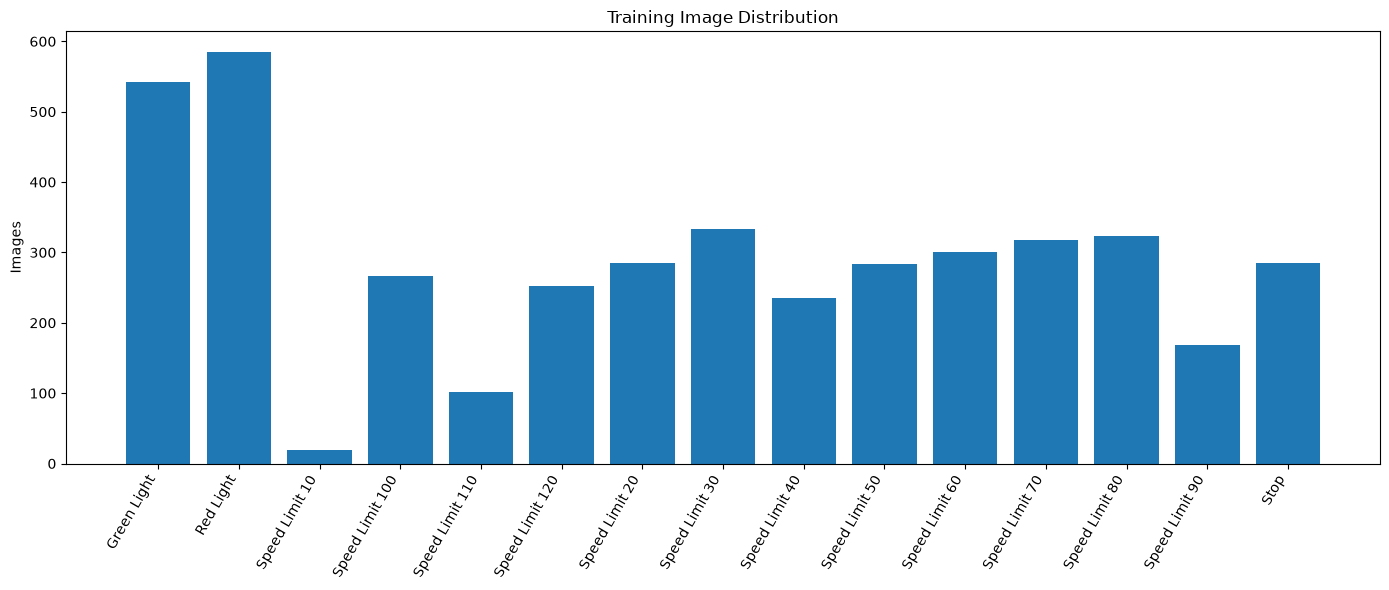

In [7]:
# ==========================================================
# 🟢 PART C - STEP 2 : Class Distribution
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

train_folder = DATASET_PATH/"train"

class_counts = {}

for cls in classes:

    count = len(list((train_folder/cls).glob("*")))

    class_counts[cls] = count

df = pd.DataFrame({

    "Class":class_counts.keys(),

    "Training Images":class_counts.values()

})

print("="*70)
print("📊 TRAINING DATASET DISTRIBUTION")
print("="*70)

display(df)

print(f"\nTotal Training Images : {df['Training Images'].sum()}")

# -----------------------------
# Plot
# -----------------------------

plt.figure(figsize=(14,6))

plt.bar(df["Class"],df["Training Images"])

plt.xticks(rotation=60,ha="right")

plt.ylabel("Images")

plt.title("Training Image Distribution")

plt.tight_layout()

plt.show()

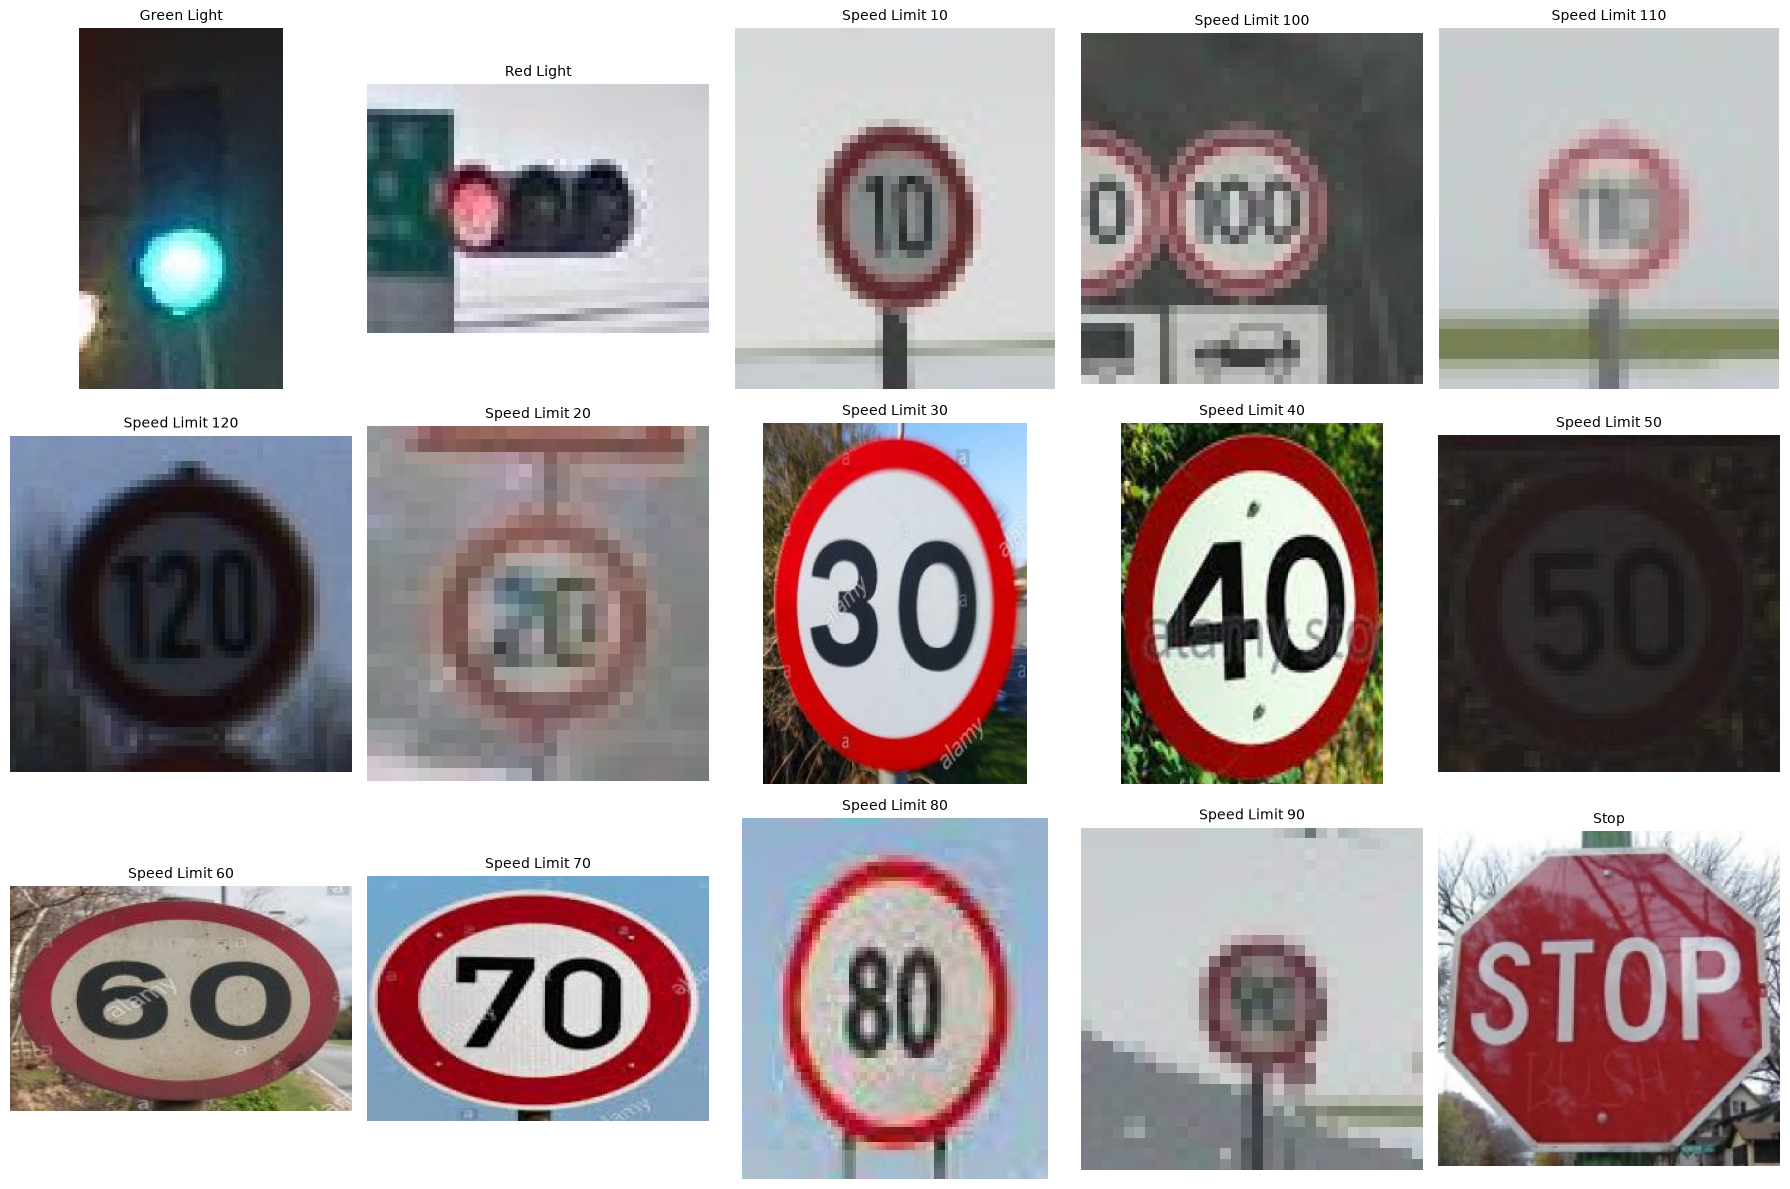

In [8]:
# ==========================================================
# 🟢 PART C - STEP 3 : Display Sample Images
# ==========================================================

import cv2
import random

plt.figure(figsize=(18,12))

for i,cls in enumerate(classes):

    folder = DATASET_PATH/"train"/cls

    image = random.choice(list(folder.glob("*")))

    img = cv2.imread(str(image))

    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    plt.subplot(3,5,i+1)

    plt.imshow(img)

    plt.title(cls,fontsize=10)

    plt.axis("off")

plt.tight_layout()

plt.show()

In [9]:
# ==========================================================
# 🟢 PART C - STEP 4 : Image Size Analysis
# ==========================================================

import cv2

widths = []
heights = []

for cls in classes:

    folder = DATASET_PATH/"train"/cls

    for img_path in folder.glob("*"):

        img = cv2.imread(str(img_path))

        if img is None:
            continue

        h,w = img.shape[:2]

        heights.append(h)

        widths.append(w)

print("="*70)
print("📐 IMAGE SIZE ANALYSIS")
print("="*70)

print(f"Minimum Width  : {min(widths)}")

print(f"Maximum Width  : {max(widths)}")

print(f"Average Width  : {sum(widths)/len(widths):.2f}")

print()

print(f"Minimum Height : {min(heights)}")

print(f"Maximum Height : {max(heights)}")

print(f"Average Height : {sum(heights)/len(heights):.2f}")

print("="*70)

📐 IMAGE SIZE ANALYSIS
Minimum Width  : 17
Maximum Width  : 414
Average Width  : 73.88

Minimum Height : 23
Maximum Height : 416
Average Height : 82.32


In [10]:
# ==========================================================
# 🟢 PART C - STEP 5 : Dataset Summary
# ==========================================================

summary = pd.DataFrame({

    "Dataset":[
        "Training",
        "Validation",
        "Testing"
    ],

    "Images":[

        sum(len(list((DATASET_PATH/"train"/cls).glob("*"))) for cls in classes),

        sum(len(list((DATASET_PATH/"valid"/cls).glob("*"))) for cls in classes),

        sum(len(list((DATASET_PATH/"test"/cls).glob("*"))) for cls in classes),

    ],

    "Classes":[15,15,15]

})

print("="*70)
print("📋 DATASET SUMMARY")
print("="*70)

display(summary)

📋 DATASET SUMMARY


,Dataset,Images,Classes
0,Training,4298,15
1,Validation,944,15
2,Testing,770,15


In [11]:
# ==========================================================
# 🟢 PART D - STEP 1 : Data Augmentation
# ==========================================================
#
# Purpose:
#     Prepare images for EfficientNet-B0.
#
# Input:
#     TrafficSign_Classification Dataset
#
# Output:
#     Training & Validation Transforms
#
# Expected Result:
#     Images are resized, augmented and normalized.
# ==========================================================

from torchvision import transforms

# -------------------------------
# Image Size
# -------------------------------

IMAGE_SIZE = 224

# -------------------------------
# Training Transform
# -------------------------------

train_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.RandomRotation(10),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)
    ),

    transforms.ColorJitter(
        brightness=0.20,
        contrast=0.20,
        saturation=0.20
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# -------------------------------
# Validation / Test Transform
# -------------------------------

test_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("="*70)
print("✅ Data Augmentation Ready")
print("="*70)

print(f"Image Size : {IMAGE_SIZE} x {IMAGE_SIZE}")

print("\nTraining Transform")
print(train_transform)

print("\nValidation/Test Transform")
print(test_transform)

✅ Data Augmentation Ready
Image Size : 224 x 224

Training Transform
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    RandomAffine(degrees=[0.0, 0.0], translate=(0.05, 0.05))
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Validation/Test Transform
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [15]:
# ==========================================================
# 🟢 PART B - STEP 2 : Fix Empty Validation/Test Classes
# ==========================================================

from pathlib import Path
import shutil

DATASET_PATH = Path(r"D:\Major Project\TrafficSign_Classification")

print("="*70)
print("🔧 Checking Empty Class Folders...")
print("="*70)

for split in ["valid", "test"]:

    print(f"\nChecking {split.upper()}")

    split_path = DATASET_PATH / split
    train_path = DATASET_PATH / "train"

    for cls in sorted(train_path.iterdir()):

        if not cls.is_dir():
            continue

        target_folder = split_path / cls.name

        images = list(target_folder.glob("*"))

        if len(images) == 0:

            train_image = list((train_path / cls.name).glob("*"))[0]

            shutil.copy(train_image, target_folder)

            print(f"✅ Added 1 image -> {split}/{cls.name}")

print("\n" + "="*70)
print("🎉 Empty folders fixed successfully!")
print("="*70)

🔧 Checking Empty Class Folders...

Checking VALID
✅ Added 1 image -> valid/Speed Limit 10

Checking TEST

🎉 Empty folders fixed successfully!


In [16]:
# ==========================================================
# 🟢 PART D - STEP 2 : Load Dataset
# ==========================================================

from torchvision.datasets import ImageFolder

train_dataset = ImageFolder(
    root=DATASET_PATH / "train",
    transform=train_transform
)

valid_dataset = ImageFolder(
    root=DATASET_PATH / "valid",
    transform=test_transform
)

test_dataset = ImageFolder(
    root=DATASET_PATH / "test",
    transform=test_transform
)

print("="*70)
print("📂 DATASET LOADED")
print("="*70)

print(f"Training Images   : {len(train_dataset)}")
print(f"Validation Images : {len(valid_dataset)}")
print(f"Testing Images    : {len(test_dataset)}")

print(f"\nClasses : {len(train_dataset.classes)}")

print("\nClass Names")

for i, name in enumerate(train_dataset.classes):
    print(f"{i:2d}. {name}")

📂 DATASET LOADED
Training Images   : 4298
Validation Images : 945
Testing Images    : 770

Classes : 15

Class Names
 0. Green Light
 1. Red Light
 2. Speed Limit 10
 3. Speed Limit 100
 4. Speed Limit 110
 5. Speed Limit 120
 6. Speed Limit 20
 7. Speed Limit 30
 8. Speed Limit 40
 9. Speed Limit 50
10. Speed Limit 60
11. Speed Limit 70
12. Speed Limit 80
13. Speed Limit 90
14. Stop


In [17]:
# ==========================================================
# 🟢 PART D - STEP 3 : Create DataLoaders
# ==========================================================

from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("="*70)
print("🚀 DATALOADERS CREATED")
print("="*70)

print(f"Batch Size : {BATCH_SIZE}")

print(f"Training Batches   : {len(train_loader)}")
print(f"Validation Batches : {len(valid_loader)}")
print(f"Testing Batches    : {len(test_loader)}")

🚀 DATALOADERS CREATED
Batch Size : 32
Training Batches   : 135
Validation Batches : 30
Testing Batches    : 25


In [18]:
# ==========================================================
# 🟢 PART D - STEP 4 : Verify DataLoader
# ==========================================================

images, labels = next(iter(train_loader))

print("="*70)
print("📦 BATCH INFORMATION")
print("="*70)

print(f"Image Batch Shape : {images.shape}")
print(f"Label Shape       : {labels.shape}")
print(f"Image Data Type   : {images.dtype}")

print("="*70)
print("✅ PART D COMPLETED")
print("="*70)

📦 BATCH INFORMATION
Image Batch Shape : torch.Size([32, 3, 224, 224])
Label Shape       : torch.Size([32])
Image Data Type   : torch.float32
✅ PART D COMPLETED


In [19]:
# ==========================================================
# 🟢 PART E - STEP 1 : Device Configuration
# ==========================================================

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("="*70)
print("🚀 DEVICE INFORMATION")
print("="*70)

print("Device :", device)

if device.type == "cuda":
    print("GPU :", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)

print("="*70)
print("✅ STEP 1 COMPLETED")
print("="*70)

🚀 DEVICE INFORMATION
Device : cuda
GPU : NVIDIA GeForce RTX 3050 6GB Laptop GPU
CUDA: 12.6
✅ STEP 1 COMPLETED


In [20]:
# ==========================================================
# 🟢 PART E - STEP 2 : Load EfficientNet-B0
# ==========================================================

from torchvision.models import efficientnet_b0
from torchvision.models import EfficientNet_B0_Weights

weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(weights=weights)

print("="*70)
print("✅ EfficientNet-B0 Loaded Successfully")
print("="*70)

print(model)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\ASUS/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100.0%

✅ EfficientNet-B0 Loaded Successfully
EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activat

In [21]:
# ==========================================================
# 🟢 PART E - STEP 3 : Freeze Model & Replace Classifier
# ==========================================================

import torch.nn as nn

NUM_CLASSES = 15

# Freeze backbone
for param in model.parameters():
    param.requires_grad = False

# Replace classifier
in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(p=0.30),
    nn.Linear(in_features, NUM_CLASSES)
)

# Move model to GPU
model = model.to(device)

print("="*70)
print("✅ Model Modified Successfully")
print("="*70)

print(f"Input Features : {in_features}")
print(f"Output Classes : {NUM_CLASSES}")

✅ Model Modified Successfully
Input Features : 1280
Output Classes : 15


In [22]:
# ==========================================================
# 🟢 PART E - STEP 4 : Trainable Parameters
# ==========================================================

total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print("="*70)
print("📊 MODEL SUMMARY")
print("="*70)

print(f"Total Parameters      : {total_params:,}")
print(f"Trainable Parameters  : {trainable_params:,}")
print(f"Frozen Parameters     : {total_params-trainable_params:,}")

print("="*70)

📊 MODEL SUMMARY
Total Parameters      : 4,026,763
Trainable Parameters  : 19,215
Frozen Parameters     : 4,007,548


In [23]:
# ==========================================================
# 🟢 PART F - STEP 1 : Calculate Class Weights
# ==========================================================

import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import torch

labels = train_dataset.targets

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("="*70)
print("⚖️ CLASS WEIGHTS")
print("="*70)

for i, weight in enumerate(class_weights):
    print(f"{train_dataset.classes[i]:<20} : {weight:.4f}")

print("="*70)

⚖️ CLASS WEIGHTS
Green Light          : 0.5287
Red Light            : 0.4898
Speed Limit 10       : 15.0807
Speed Limit 100      : 1.0732
Speed Limit 110      : 2.8370
Speed Limit 120      : 1.1370
Speed Limit 20       : 1.0054
Speed Limit 30       : 0.8579
Speed Limit 40       : 1.2193
Speed Limit 50       : 1.0125
Speed Limit 60       : 0.9519
Speed Limit 70       : 0.9010
Speed Limit 80       : 0.8871
Speed Limit 90       : 1.7056
Stop                 : 1.0054


In [24]:
# ==========================================================
# 🟢 PART F - STEP 2 : Loss Function
# ==========================================================

import torch.nn as nn

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print("="*70)
print("✅ CrossEntropyLoss Created")
print("="*70)

✅ CrossEntropyLoss Created


In [25]:
# ==========================================================
# 🟢 PART F - STEP 3 : Optimizer
# ==========================================================

import torch.optim as optim

optimizer = optim.Adam(

    model.classifier.parameters(),

    lr=0.001

)

print("="*70)
print("✅ Optimizer Ready")
print("="*70)

✅ Optimizer Ready


In [26]:
# ==========================================================
# 🟢 PART F - STEP 4 : Learning Rate Scheduler
# ==========================================================

scheduler = optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=0.2,

    patience=3

)

print("="*70)
print("✅ Learning Rate Scheduler Ready")
print("="*70)

✅ Learning Rate Scheduler Ready


In [27]:
# ==========================================================
# 🟢 PART G - STEP 1 : Training Configuration
# ==========================================================

EPOCHS = 30

BEST_MODEL_PATH = r"D:\Major Project\Classification_Models"

import os

os.makedirs(BEST_MODEL_PATH, exist_ok=True)

print("="*70)
print("🚀 TRAINING CONFIGURATION")
print("="*70)

print(f"Epochs           : {EPOCHS}")
print(f"Batch Size       : {BATCH_SIZE}")
print(f"Learning Rate    : 0.001")
print(f"Best Model Path  : {BEST_MODEL_PATH}")

print("="*70)

🚀 TRAINING CONFIGURATION
Epochs           : 30
Batch Size       : 32
Learning Rate    : 0.001
Best Model Path  : D:\Major Project\Classification_Models


In [28]:
# ==========================================================
# 🟢 PART G - STEP 2 : Train EfficientNet-B0
# ==========================================================

import torch
import time

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_loss = float("inf")
patience = 5
counter = 0

print("="*70)
print("🚀 TRAINING STARTED")
print("="*70)

start_time = time.time()

for epoch in range(EPOCHS):

    # ----------------------------
    # TRAIN
    # ----------------------------

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)

        correct += (predicted==labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    # ----------------------------
    # VALIDATION
    # ----------------------------

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs,1)

            total += labels.size(0)

            correct += (predicted==labels).sum().item()

    val_loss = running_loss / len(valid_loader)
    val_acc = 100 * correct / total

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}]")

    print(f"Train Loss : {train_loss:.4f} | Train Acc : {train_acc:.2f}%")

    print(f"Val Loss   : {val_loss:.4f} | Val Acc   : {val_acc:.2f}%")

    print("-"*70)

    # ----------------------------
    # SAVE BEST MODEL
    # ----------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            os.path.join(
                BEST_MODEL_PATH,
                "best_efficientnet_b0.pth"
            )
        )

        counter = 0

        print("✅ Best Model Saved\n")

    else:

        counter += 1

        if counter >= patience:

            print("\n🛑 Early Stopping Triggered!")

            break

training_time = time.time()-start_time

print("="*70)

print("🎉 TRAINING COMPLETED")

print("="*70)

print(f"Training Time : {training_time/60:.2f} minutes")

🚀 TRAINING STARTED
Epoch [1/30]
Train Loss : 1.9552 | Train Acc : 46.49%
Val Loss   : 1.4512 | Val Acc   : 60.53%
----------------------------------------------------------------------
✅ Best Model Saved

Epoch [2/30]
Train Loss : 1.3958 | Train Acc : 61.61%
Val Loss   : 1.1727 | Val Acc   : 67.83%
----------------------------------------------------------------------
✅ Best Model Saved

Epoch [3/30]
Train Loss : 1.1996 | Train Acc : 66.82%
Val Loss   : 1.0547 | Val Acc   : 70.16%
----------------------------------------------------------------------
✅ Best Model Saved

Epoch [4/30]
Train Loss : 1.1088 | Train Acc : 68.66%
Val Loss   : 0.9670 | Val Acc   : 72.59%
----------------------------------------------------------------------
✅ Best Model Saved

Epoch [5/30]
Train Loss : 1.0427 | Train Acc : 69.66%
Val Loss   : 0.9187 | Val Acc   : 74.50%
----------------------------------------------------------------------
✅ Best Model Saved

Epoch [6/30]
Train Loss : 1.0060 | Train Acc : 71.1

In [34]:
# ==========================================================
# 🟢 PART H - STEP 1 : Load Best Model
# ==========================================================

import os
import torch

BEST_MODEL = os.path.join(
    BEST_MODEL_PATH,
    "best_efficientnet_b0.pth"
)

model.load_state_dict(
    torch.load(
        BEST_MODEL,
        map_location=device
    )
)

print("="*70)
print("✅ Best Stage-1 Model Loaded")
print("="*70)
print(BEST_MODEL)

✅ Best Stage-1 Model Loaded
D:\Major Project\Classification_Models\best_efficientnet_b0.pth


In [30]:
# ==========================================================
# 🟢 PART H - STEP 2 : Fine-Tuning Setup
# ==========================================================

# Freeze everything again
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last feature block
for param in model.features[-1].parameters():
    param.requires_grad = True

# Classifier also remains trainable
for param in model.classifier.parameters():
    param.requires_grad = True

print("="*70)
print("✅ Fine-Tuning Enabled")
print("="*70)

trainable = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Trainable Parameters : {trainable:,}")

✅ Fine-Tuning Enabled
Trainable Parameters : 431,375


In [31]:
# ==========================================================
# 🟢 PART H - STEP 3 : Optimizer
# ==========================================================

optimizer = torch.optim.Adam(

    filter(lambda p: p.requires_grad, model.parameters()),

    lr=0.0001

)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=0.2,

    patience=2

)

print("="*70)
print("✅ Fine-Tuning Optimizer Ready")
print("="*70)

✅ Fine-Tuning Optimizer Ready


In [32]:
# ==========================================================
# 🟢 PART H - STEP 4 : Configuration
# ==========================================================

FINE_TUNE_EPOCHS = 15

print("="*70)
print("🚀 FINE-TUNING CONFIGURATION")
print("="*70)

print(f"Epochs : {FINE_TUNE_EPOCHS}")
print("Learning Rate : 0.0001")
print("Early Stopping : 5")

🚀 FINE-TUNING CONFIGURATION
Epochs : 15
Learning Rate : 0.0001
Early Stopping : 5


In [35]:
# ==========================================================
# 🟢 PART H - STEP 5 : Fine-Tune EfficientNet-B0
# ==========================================================

import time
import torch
import os

# ----------------------------------------------------------
# Best validation loss from Stage-1
# ----------------------------------------------------------

best_val_loss = 0.6697

history_finetune = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

patience = 5
counter = 0

print("=" * 70)
print("🚀 STAGE 2 : FINE-TUNING STARTED")
print("=" * 70)

start_time = time.time()

for epoch in range(FINE_TUNE_EPOCHS):

    # ======================================================
    # TRAINING
    # ======================================================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    # ======================================================
    # VALIDATION
    # ======================================================

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(valid_loader)
    val_acc = 100 * correct / total

    scheduler.step(val_loss)

    # ======================================================
    # STORE HISTORY
    # ======================================================

    history_finetune["train_loss"].append(train_loss)
    history_finetune["train_acc"].append(train_acc)

    history_finetune["val_loss"].append(val_loss)
    history_finetune["val_acc"].append(val_acc)

    # ======================================================
    # PRINT RESULTS
    # ======================================================

    current_lr = optimizer.param_groups[0]["lr"]

    print("\n" + "=" * 70)
    print(f"Fine-Tune Epoch [{epoch+1}/{FINE_TUNE_EPOCHS}]")
    print("=" * 70)

    print(f"Learning Rate : {current_lr:.6f}")

    print(f"Train Loss    : {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.2f}%")

    print(f"Val Loss      : {val_loss:.4f}")
    print(f"Val Accuracy  : {val_acc:.2f}%")

    # ======================================================
    # SAVE BEST MODEL
    # ======================================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            os.path.join(
                BEST_MODEL_PATH,
                "best_efficientnet_b0_finetuned.pth"
            )
        )

        counter = 0

        print("\n✅ New Best Fine-Tuned Model Saved")

    else:

        counter += 1

        print(f"\n⏳ Early Stopping Counter : {counter}/{patience}")

        if counter >= patience:

            print("\n🛑 Early Stopping Triggered!")

            break

# ==========================================================
# TRAINING FINISHED
# ==========================================================

training_time = time.time() - start_time

print("\n" + "=" * 70)
print("🎉 STAGE 2 COMPLETED")
print("=" * 70)

print(f"Fine-Tuning Time : {training_time/60:.2f} minutes")
print(f"Best Validation Loss : {best_val_loss:.4f}")

print("\nBest Model Saved At:")

print(
    os.path.join(
        BEST_MODEL_PATH,
        "best_efficientnet_b0_finetuned.pth"
    )
)

print("=" * 70)

🚀 STAGE 2 : FINE-TUNING STARTED

Fine-Tune Epoch [1/15]
Learning Rate : 0.000100
Train Loss    : 0.7497
Train Accuracy: 77.57%
Val Loss      : 0.6485
Val Accuracy  : 78.10%

✅ New Best Fine-Tuned Model Saved

Fine-Tune Epoch [2/15]
Learning Rate : 0.000100
Train Loss    : 0.7159
Train Accuracy: 77.97%
Val Loss      : 0.6381
Val Accuracy  : 79.05%

✅ New Best Fine-Tuned Model Saved

Fine-Tune Epoch [3/15]
Learning Rate : 0.000100
Train Loss    : 0.6975
Train Accuracy: 78.80%
Val Loss      : 0.6082
Val Accuracy  : 79.26%

✅ New Best Fine-Tuned Model Saved

Fine-Tune Epoch [4/15]
Learning Rate : 0.000100
Train Loss    : 0.6682
Train Accuracy: 79.71%
Val Loss      : 0.5897
Val Accuracy  : 80.11%

✅ New Best Fine-Tuned Model Saved

Fine-Tune Epoch [5/15]
Learning Rate : 0.000100
Train Loss    : 0.6653
Train Accuracy: 79.53%
Val Loss      : 0.5752
Val Accuracy  : 81.06%

✅ New Best Fine-Tuned Model Saved

Fine-Tune Epoch [6/15]
Learning Rate : 0.000100
Train Loss    : 0.6177
Train Accuracy: 

In [36]:
# ==========================================================
# 🟢 PART I - STEP 1 : Load Best Fine-Tuned Model
# ==========================================================

import os
import torch

BEST_MODEL = os.path.join(
    BEST_MODEL_PATH,
    "best_efficientnet_b0_finetuned.pth"
)

model.load_state_dict(
    torch.load(BEST_MODEL, map_location=device)
)

model = model.to(device)
model.eval()

print("="*70)
print("✅ Best Fine-Tuned Model Loaded Successfully")
print("="*70)
print(BEST_MODEL)

✅ Best Fine-Tuned Model Loaded Successfully
D:\Major Project\Classification_Models\best_efficientnet_b0_finetuned.pth


In [37]:
# ==========================================================
# 🟢 PART I - STEP 2 : Test Evaluation
# ==========================================================

import torch

test_loss = 0
correct = 0
total = 0

all_labels = []
all_predictions = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

test_loss /= len(test_loader)

test_accuracy = 100 * correct / total

print("="*70)
print("📊 TEST RESULTS")
print("="*70)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.2f}%")

print("="*70)

📊 TEST RESULTS
Test Loss     : 0.5076
Test Accuracy : 82.60%


In [38]:
# ==========================================================
# 🟢 PART I - STEP 3 : Classification Report
# ==========================================================

from sklearn.metrics import classification_report

print("="*70)
print("📋 CLASSIFICATION REPORT")
print("="*70)

print(

    classification_report(

        all_labels,

        all_predictions,

        target_names=train_dataset.classes,

        digits=4

    )

)

📋 CLASSIFICATION REPORT
                 precision    recall  f1-score   support

    Green Light     0.9123    0.9455    0.9286       110
      Red Light     0.9121    0.8830    0.8973        94
 Speed Limit 10     0.7500    1.0000    0.8571         3
Speed Limit 100     0.8333    0.7609    0.7955        46
Speed Limit 110     0.7727    0.8095    0.7907        21
Speed Limit 120     0.7333    0.7500    0.7416        44
 Speed Limit 20     0.8600    0.9348    0.8958        46
 Speed Limit 30     0.8462    0.5500    0.6667        60
 Speed Limit 40     0.8148    0.8302    0.8224        53
 Speed Limit 50     0.7400    0.7400    0.7400        50
 Speed Limit 60     0.7143    0.7778    0.7447        45
 Speed Limit 70     0.7500    0.8491    0.7965        53
 Speed Limit 80     0.7727    0.8361    0.8031        61
 Speed Limit 90     0.6944    0.7353    0.7143        34
           Stop     1.0000    0.9600    0.9796        50

       accuracy                         0.8260       770
     

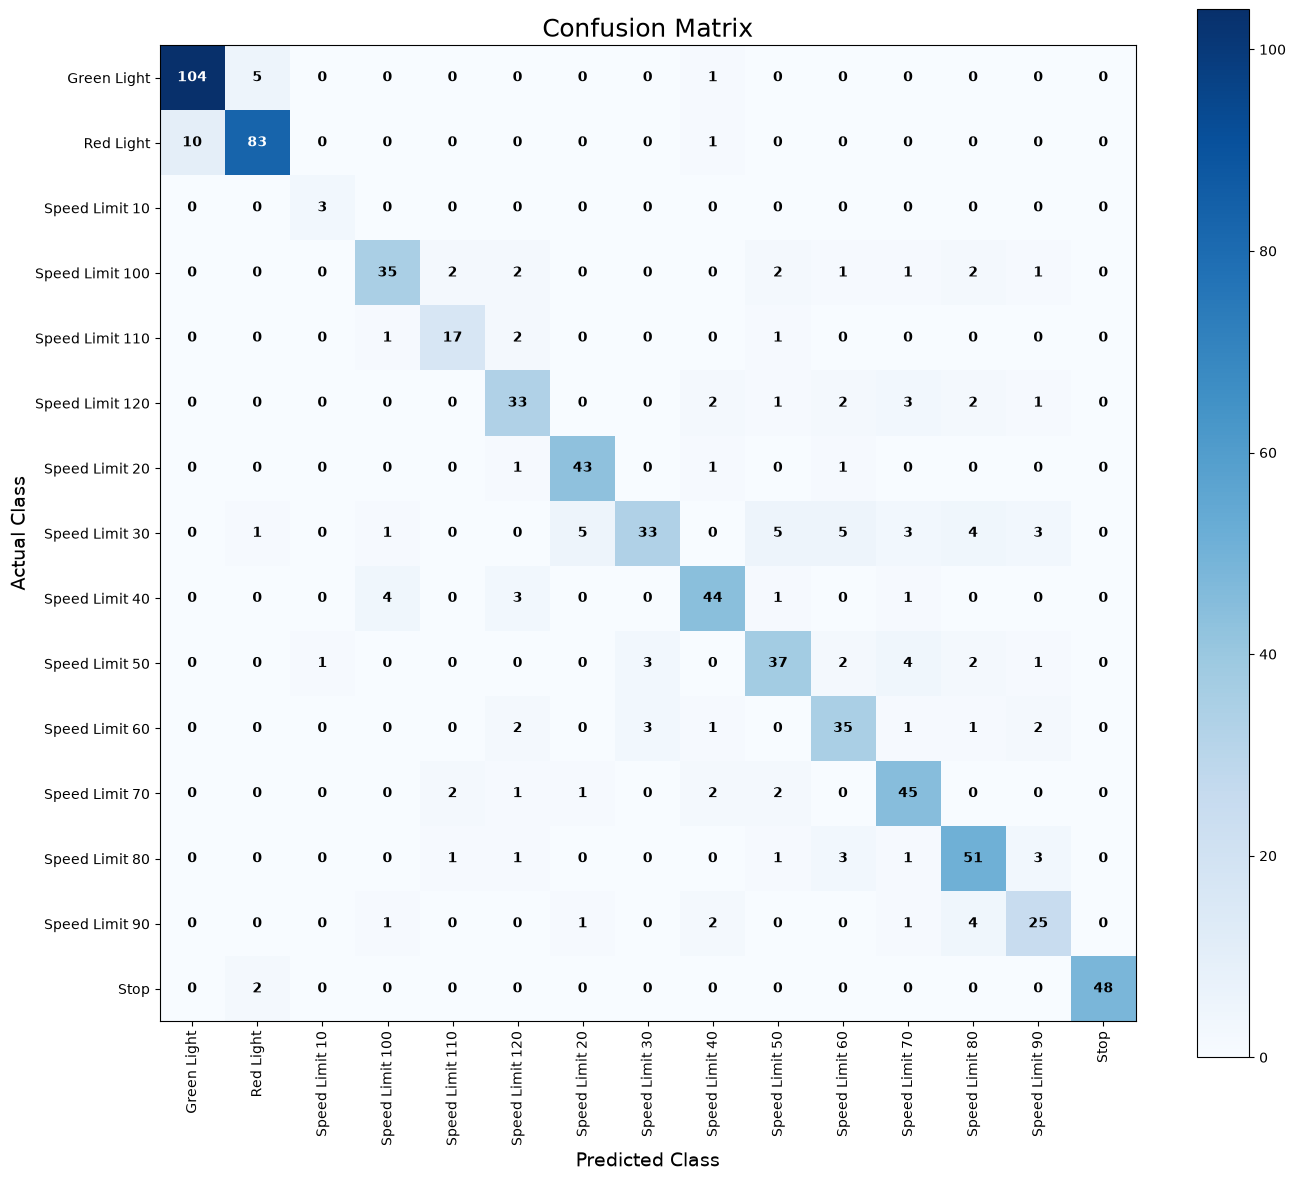

In [41]:
# ==========================================================
# 🟢 PART I - STEP 4 : Confusion Matrix (With Numbers)
# ==========================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Compute Confusion Matrix
cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(14, 12))

plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix", fontsize=18)
plt.colorbar()

classes = train_dataset.classes

plt.xticks(np.arange(len(classes)), classes, rotation=90)
plt.yticks(np.arange(len(classes)), classes)

# ----------------------------------------------------------
# Write Numbers Inside Cells
# ----------------------------------------------------------

threshold = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            color="white" if cm[i, j] > threshold else "black",
            fontsize=10,
            fontweight="bold"
        )

plt.xlabel("Predicted Class", fontsize=14)
plt.ylabel("Actual Class", fontsize=14)

plt.tight_layout()
plt.show()

In [42]:
# ==========================================================
# 🟢 PART I - STEP 5 : Overall Metrics
# ==========================================================

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted"
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted"
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted"
)

print("="*70)
print("📊 OVERALL PERFORMANCE")
print("="*70)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("="*70)

📊 OVERALL PERFORMANCE
Precision : 0.8290
Recall    : 0.8260
F1 Score  : 0.8242


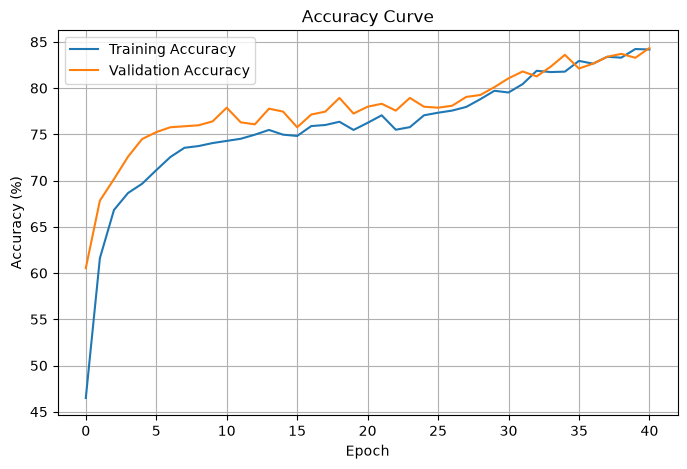

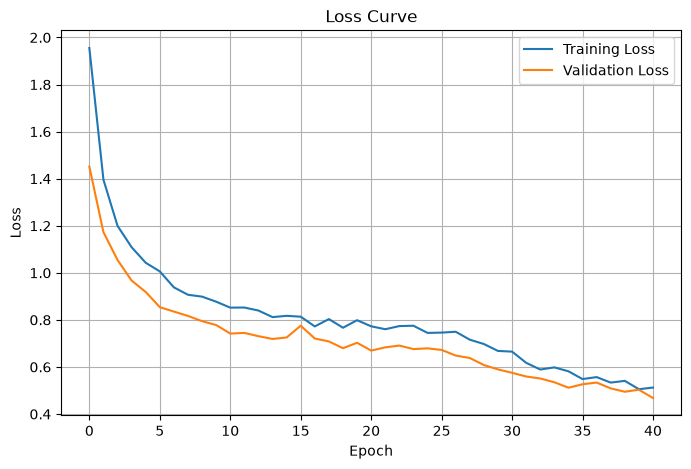

In [43]:
# ==========================================================
# 🟢 PART I - STEP 6 : Accuracy & Loss Curves
# ==========================================================

import matplotlib.pyplot as plt

train_acc = history["train_acc"] + history_finetune["train_acc"]
val_acc = history["val_acc"] + history_finetune["val_acc"]

train_loss = history["train_loss"] + history_finetune["train_loss"]
val_loss = history["val_loss"] + history_finetune["val_loss"]

# -----------------------------
# Accuracy
# -----------------------------

plt.figure(figsize=(8,5))

plt.plot(train_acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")

plt.title("Accuracy Curve")

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.legend()

plt.grid(True)

plt.show()

# -----------------------------
# Loss
# -----------------------------

plt.figure(figsize=(8,5))

plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")

plt.title("Loss Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [3]:
# ==========================================================
# 🟢 STEP 1 : Load Best Fine-Tuned Model
# (RUN EVERY TIME AFTER RESTART)
# ==========================================================

import os
import torch
import torch.nn as nn
from pathlib import Path
from torchvision.models import efficientnet_b0
from torchvision.models import EfficientNet_B0_Weights

# ----------------------------------------------------------
# Device
# ----------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------------------------------------
# Dataset Path
# ----------------------------------------------------------

DATASET_PATH = Path(r"D:\Major Project\TrafficSign_Classification")

# ----------------------------------------------------------
# Automatically Read Class Names
# ----------------------------------------------------------

CLASS_NAMES = sorted(
    [folder.name for folder in (DATASET_PATH / "train").iterdir()
     if folder.is_dir()]
)

NUM_CLASSES = len(CLASS_NAMES)

# ----------------------------------------------------------
# Load EfficientNet-B0
# ----------------------------------------------------------

weights = EfficientNet_B0_Weights.DEFAULT

prediction_model = efficientnet_b0(weights=weights)

# ----------------------------------------------------------
# Replace Classifier
# ----------------------------------------------------------

in_features = prediction_model.classifier[1].in_features

prediction_model.classifier = nn.Sequential(
    nn.Dropout(0.30),
    nn.Linear(in_features, NUM_CLASSES)
)

# ----------------------------------------------------------
# Model Path
# ----------------------------------------------------------

MODEL_PATH = r"D:\Major Project\Classification_Models\best_efficientnet_b0_finetuned.pth"

# ----------------------------------------------------------
# Check Model
# ----------------------------------------------------------

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"\nModel Not Found:\n{MODEL_PATH}"
    )

# ----------------------------------------------------------
# Load Model
# ----------------------------------------------------------

prediction_model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device,
        weights_only=True
    )
)
prediction_model = prediction_model.to(device)

prediction_model.eval()

# ----------------------------------------------------------
# Model Summary
# ----------------------------------------------------------

print("=" * 70)
print("🚀 EFFICIENTNET-B0 CLASSIFICATION MODEL")
print("=" * 70)

print(f"Device           : {device}")

if device.type == "cuda":
    print(f"GPU              : {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version     : {torch.version.cuda}")

print(f"\nModel Path")
print(MODEL_PATH)

print(f"\nNumber of Classes : {NUM_CLASSES}")

print("\nClass Names")

for i, cls in enumerate(CLASS_NAMES):
    print(f"{i:2d}. {cls}")

print("\n" + "=" * 70)
print("✅ MODEL LOADED SUCCESSFULLY")
print("🚀 READY FOR PREDICTION")
print("=" * 70)

🚀 EFFICIENTNET-B0 CLASSIFICATION MODEL
Device           : cuda
GPU              : NVIDIA GeForce RTX 3050 6GB Laptop GPU
CUDA Version     : 12.6

Model Path
D:\Major Project\Classification_Models\best_efficientnet_b0_finetuned.pth

Number of Classes : 15

Class Names
 0. Green Light
 1. Red Light
 2. Speed Limit 10
 3. Speed Limit 100
 4. Speed Limit 110
 5. Speed Limit 120
 6. Speed Limit 20
 7. Speed Limit 30
 8. Speed Limit 40
 9. Speed Limit 50
10. Speed Limit 60
11. Speed Limit 70
12. Speed Limit 80
13. Speed Limit 90
14. Stop

✅ MODEL LOADED SUCCESSFULLY
🚀 READY FOR PREDICTION


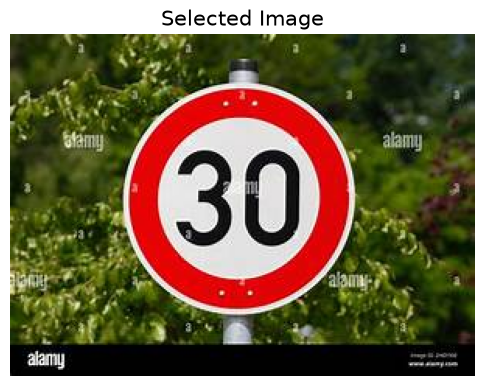

🚦 TRAFFIC SIGN CLASSIFICATION
📂 Image : D:/Major Project/Test_images/speed30_1.jpg

🏆 Prediction : Speed Limit 50
🎯 Confidence : 62.33%
⚡ Inference Time : 13.75 ms


,Rank,Predicted Class,Confidence (%)
0,1,Speed Limit 50,62.330002
1,2,Speed Limit 30,20.190001
2,3,Speed Limit 60,10.350000


✅ Prediction Completed Successfully


In [6]:
# ==========================================================
# 🔵 STEP 2 : Select Image & Predict
# (RUN ANYTIME)
# ==========================================================

import time
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tkinter import Tk, filedialog
from torchvision import transforms

# ----------------------------------------------------------
# Image Transform
# ----------------------------------------------------------

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# ----------------------------------------------------------
# Select Image
# ----------------------------------------------------------

root = Tk()
root.withdraw()
root.attributes('-topmost', True)

image_path = filedialog.askopenfilename(
    title="Select Traffic Sign Image",
    filetypes=[
        ("Image Files","*.jpg *.jpeg *.png *.bmp *.webp")
    ]
)

root.destroy()

if image_path == "":
    print("❌ No Image Selected")
    raise SystemExit

# ----------------------------------------------------------
# Read Image
# ----------------------------------------------------------

image = Image.open(image_path).convert("RGB")

display_image = np.array(image)

input_tensor = transform(image).unsqueeze(0).to(device)

# ----------------------------------------------------------
# Prediction
# ----------------------------------------------------------

start = time.time()

with torch.no_grad():

    outputs = prediction_model(input_tensor)

    probabilities = torch.softmax(outputs, dim=1)

end = time.time()

# ----------------------------------------------------------
# Top-3 Predictions
# ----------------------------------------------------------

top_prob, top_class = torch.topk(probabilities, 3)

top_prob = top_prob.cpu().numpy()[0]
top_class = top_class.cpu().numpy()[0]

# ----------------------------------------------------------
# Display Image
# ----------------------------------------------------------

plt.figure(figsize=(6,6))

plt.imshow(display_image)

plt.axis("off")

plt.title("Selected Image", fontsize=15)

plt.show()

# ----------------------------------------------------------
# Prediction Table
# ----------------------------------------------------------

prediction_df = pd.DataFrame({

    "Rank":[1,2,3],

    "Predicted Class":[
        CLASS_NAMES[top_class[0]],
        CLASS_NAMES[top_class[1]],
        CLASS_NAMES[top_class[2]]
    ],

    "Confidence (%)":[
        round(top_prob[0]*100,2),
        round(top_prob[1]*100,2),
        round(top_prob[2]*100,2)
    ]

})

# ----------------------------------------------------------
# Final Output
# ----------------------------------------------------------

print("="*70)
print("🚦 TRAFFIC SIGN CLASSIFICATION")
print("="*70)

print(f"📂 Image : {image_path}")

print(f"\n🏆 Prediction : {CLASS_NAMES[top_class[0]]}")

print(f"🎯 Confidence : {top_prob[0]*100:.2f}%")

print(f"⚡ Inference Time : {(end-start)*1000:.2f} ms")

print("="*70)

display(prediction_df)

print("="*70)
print("✅ Prediction Completed Successfully")
print("="*70)